## Step 7 — Readiness Trigger (GloFAS)

Evaluates the GloFAS station-based readiness trigger for a given state. Given a **return period threshold**, this notebook computes detection stats (POD, FAR, F1) across all available lead times in the ensemble reforecast, scored against the Floodscan benchmark.

**Inputs:**
- GloFAS reanalysis parquet (processed blob) — for empirical threshold estimation
- GloFAS ensemble reforecast parquet (processed blob) — for lead-time scoring
- `{state}_floodscan_annual.parquet` — Floodscan flood event flags from Step 2

**Adjust `STATE` and `RP_THRESH` in the Config cell.**

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv

from src.constants import PROJECT_PREFIX, STATE_CONFIG
from src.datasources.glofas import get_blob_name
from src.utils.rp_calc import empirical_return_periods

load_dotenv()

In [11]:
# ── State ──────────────────────────────────────────────────────────────────────
STATE = "Benue"  # "Adamawa" or "Benue"

# ── Trigger parameter — adjust this ───────────────────────────────────────────
RP_THRESH = 4  # return period for GloFAS discharge threshold (years)

# ── Fixed config ───────────────────────────────────────────────────────────────
WET_MONTHS   = [8, 9, 10, 11]
FS_RP_LEVELS = [3, 4, 5]

cfg                 = STATE_CONFIG[STATE]
ANALYSIS_START_YEAR = cfg["analysis_start_year"]
ANALYSIS_END_YEAR   = cfg["analysis_end_year"]

BLOB_FS_ANN = (
    f"{PROJECT_PREFIX}/processed/workflow/"
    f"{STATE.lower()}_floodscan_annual.parquet"
)

FIGURES_DIR = Path(f"figures/{STATE.lower()}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Config: {STATE} | GloFAS {cfg['glofas_station']} | {RP_THRESH}-yr RP threshold")

Config: Benue | GloFAS makurdi | 4-yr RP threshold


## Load Data

In [ ]:
# GloFAS reanalysis → empirical threshold at RP_THRESH
blob_ra  = get_blob_name("processed", "reanalysis", cfg["glofas_station"])
df_ra    = stratus.load_parquet_from_blob(blob_ra)
df_ra["time"]  = pd.to_datetime(df_ra["time"])
df_ra["year"]  = df_ra["time"].dt.year
df_ra["month"] = df_ra["time"].dt.month

dis_col   = next(c for c in df_ra.columns if c.lower() in ("dis24", "discharge"))
df_ra_wet = df_ra[
    df_ra["month"].isin(WET_MONTHS)
    & df_ra["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].copy()
df_ra_wet["date"] = df_ra_wet["time"]

df_rp     = empirical_return_periods(
    df_ra_wet, date_col="date", val_col=dis_col, target_rps=[RP_THRESH]
)
threshold = float(df_rp["value"].iloc[0])
print(
    f"{cfg['glofas_station'].title()} reanalysis: "
    f"{RP_THRESH}-yr RP threshold = {threshold:.1f} m³/s"
)
print(f"  (empirical, {df_ra_wet['year'].nunique()} wet-season years)")

In [13]:
# Floodscan event years from workflow blob
df_fs_ann = stratus.load_parquet_from_blob(BLOB_FS_ANN)
fs_event_years = {
    rp: set(df_fs_ann[df_fs_ann[f"flood_{rp}yr"] == 1]["year"])
    for rp in FS_RP_LEVELS
}
for rp, yrs in fs_event_years.items():
    print(f"  Floodscan {rp}-yr events ({len(yrs)}): {sorted(yrs)}")

  Floodscan 3-yr events (9): [1998, 2012, 2014, 2015, 2016, 2017, 2018, 2019, 2022]
  Floodscan 4-yr events (6): [2012, 2014, 2015, 2016, 2019, 2022]
  Floodscan 5-yr events (5): [2012, 2014, 2015, 2019, 2022]


In [14]:
# GloFAS reforecast → ensemble mean per (issue_time, valid_time, leadtime)
df_rf = stratus.load_parquet_from_blob(cfg["glofas_reforecast_blob"])
df_rf["time"]       = pd.to_datetime(df_rf["time"])
df_rf["valid_time"] = pd.to_datetime(df_rf["valid_time"])

ens = (
    df_rf.groupby(["time", "valid_time", "leadtime"])["dis24"]
    .mean()
    .reset_index()
    .rename(columns={"dis24": "discharge"})
)
ens["year"]  = ens["valid_time"].dt.year
ens["month"] = ens["valid_time"].dt.month

lead_times = sorted(ens["leadtime"].unique())
print(f"Lead times: {lead_times[0]}\u2013{lead_times[-1]} days ({len(lead_times)} steps)")

# Complete years: wet-season valid_time reaches at least October
ens_wet        = ens[ens["month"].isin(WET_MONTHS)]
years_with_oct = set(ens_wet[ens_wet["month"] == 10]["year"])
rf_complete_years = sorted(
    y for y in ens_wet["year"].unique()
    if ANALYSIS_START_YEAR <= y <= ANALYSIS_END_YEAR and y in years_with_oct
)
print(f"Complete reforecast years ({len(rf_complete_years)}): {rf_complete_years}")

Lead times: 1–16 days (16 steps)
Complete reforecast years (21): [np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]


## Detection Stats by Lead Time

A year is **triggered** if the ensemble mean GloFAS discharge exceeds the threshold on at least one wet-season day at the given lead time. Performance is scored against Floodscan flood years across all complete reforecast years.

In [15]:
rows = []
for lt in lead_times:
    ens_lt = ens_wet[
        (ens_wet["leadtime"] == lt) & (ens_wet["year"].isin(rf_complete_years))
    ]
    ann_max   = ens_lt.groupby("year")["discharge"].max()
    triggered = set(ann_max[ann_max > threshold].index)

    for rp in FS_RP_LEVELS:
        events = fs_event_years[rp] & set(rf_complete_years)
        tp   = len(triggered & events)
        fp   = len(triggered - events)
        fn   = len(events - triggered)
        pod  = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        far  = fp / (tp + fp) if (tp + fp) > 0 else np.nan
        f1   = (
            2 * pod * prec / (pod + prec)
            if (pod and prec and (pod + prec) > 0)
            else np.nan
        )
        rows.append({
            "leadtime": lt,
            "fs_rp":    rp,
            "n_eval":   len(rf_complete_years),
            "tp": tp, "fp": fp, "fn": fn,
            "pod": round(pod, 3) if not np.isnan(pod) else np.nan,
            "far": round(far, 3) if not np.isnan(far) else np.nan,
            "f1":  round(f1,  3) if not np.isnan(f1)  else np.nan,
        })

df_perf = pd.DataFrame(rows)

# Best configuration by F1 for each Floodscan RP level
best_rows = []
for rp in FS_RP_LEVELS:
    sub = df_perf[df_perf["fs_rp"] == rp]
    row = sub.loc[sub["f1"].idxmax()]
    best_rows.append({
        "Floodscan RP":    f"{rp}-yr",
        "Best LT (days)": int(row["leadtime"]),
        "POD": row["pod"],
        "FAR": row["far"],
        "F1":  row["f1"],
        "TP":  int(row["tp"]),
        "FP":  int(row["fp"]),
        "FN":  int(row["fn"]),
    })

df_best = pd.DataFrame(best_rows).set_index("Floodscan RP")
print("Best configurations by F1:")
df_best

Best configurations by F1:


,Best LT (days),POD,FAR,F1,TP,FP,FN
Floodscan RP,,,,,,,
3-yr,10,0.500,0.0,0.667,4,0,4
4-yr,10,0.667,0.0,0.800,4,0,2
5-yr,3,0.600,0.0,0.750,3,0,2


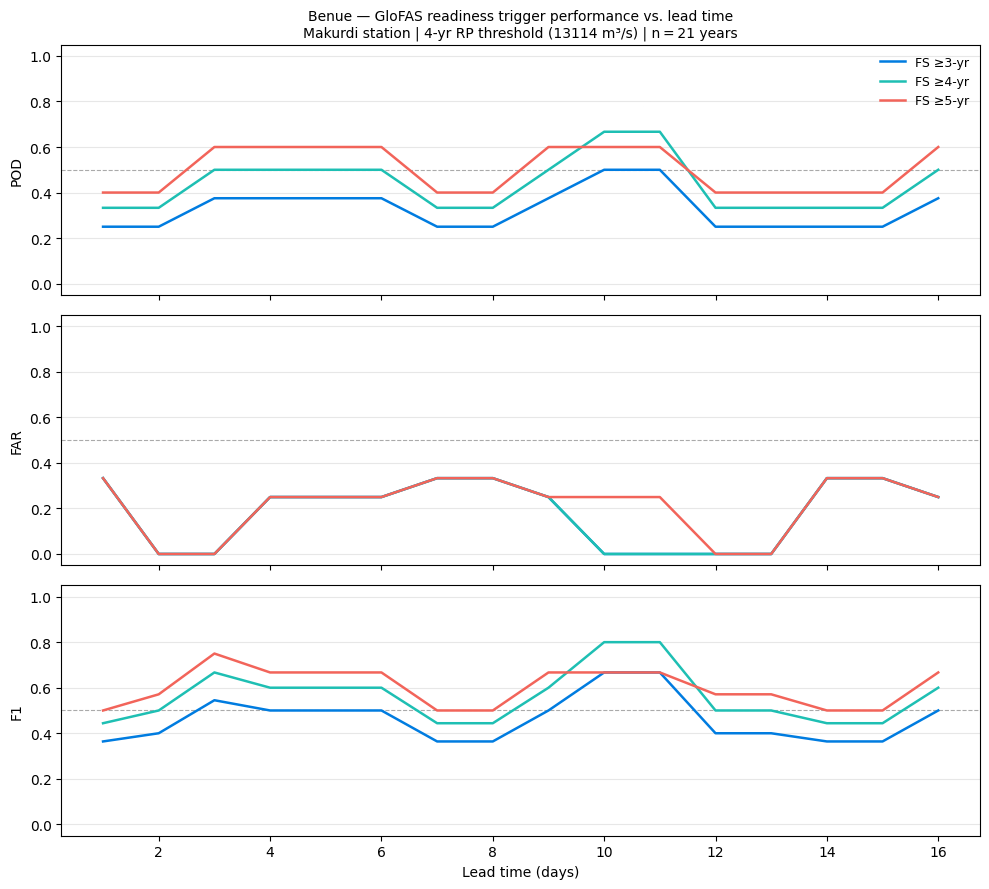

In [16]:
COLORS = {3: "#007CE0", 4: "#1EBFB3", 5: "#F2645A"}

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
metrics   = [("pod", "POD"), ("far", "FAR"), ("f1", "F1")]

for ax, (metric, label) in zip(axes, metrics):
    for rp in FS_RP_LEVELS:
        sub = df_perf[df_perf["fs_rp"] == rp].sort_values("leadtime")
        ax.plot(
            sub["leadtime"], sub[metric],
            color=COLORS[rp], label=f"FS \u2265{rp}-yr", linewidth=1.8,
        )
    ax.set_ylabel(label, fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color="#AAAAAA", linewidth=0.8, linestyle="--", zorder=0)
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xlabel("Lead time (days)", fontsize=10)
axes[0].legend(frameon=False, fontsize=9)
axes[0].set_title(
    f"{STATE} \u2014 GloFAS readiness trigger performance vs. lead time\n"
    f"{cfg['glofas_station'].title()} station | "
    f"{RP_THRESH}-yr RP threshold ({threshold:.0f} m\u00b3/s) | "
    f"n\u2009=\u2009{len(rf_complete_years)} years",
    fontsize=10,
)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / f"07_readiness_trigger_rp{RP_THRESH}.png",
    dpi=150, bbox_inches="tight",
)
plt.show()